In [15]:
!nvidia-smi

Sun Sep  6 03:53:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P0             31W /   70W |     435MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
!pip install cudf-cu12 --extra-index-url=https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com


In [17]:
!wget -q https://datasets.imdbws.com/title.principals.tsv.gz
!gunzip -f title.principals.tsv.gz
!wc -l title.principals.tsv

101623789 title.principals.tsv


In [18]:
import pandas as pd
import time

start = time.time()
df_cpu = pd.read_csv("title.principals.tsv", sep="\t", nrows=5_000_000)
result_cpu = df_cpu.groupby("category")["nconst"].count()
cpu_time = time.time() - start

print(result_cpu)
print(f"\nCPU time (load + groupby): {cpu_time:.4f} seconds")

category
actor                  1731480
actress                 991649
archive_footage          32502
archive_sound              584
casting_director         44208
cinematographer         276448
composer                206272
director                388189
editor                  238774
producer                282900
production_designer      91394
self                    224328
writer                  491272
Name: nconst, dtype: int64

CPU time (load + groupby): 10.2767 seconds


In [19]:
import cudf
import time

start = time.time()
df_gpu = cudf.read_csv("title.principals.tsv", sep="\t", nrows=5_000_000)
result_gpu = df_gpu.groupby("category")["nconst"].count()
gpu_time = time.time() - start

print(result_gpu)
print(f"\nGPU time (load + groupby): {gpu_time:.4f} seconds")

category
director                388189
cinematographer         276448
self                    224328
casting_director         44208
archive_footage          32502
actor                  1731480
composer                206272
production_designer      91394
producer                282900
archive_sound              584
writer                  491272
actress                 991649
editor                  238774
Name: nconst, dtype: int64

GPU time (load + groupby): 0.2592 seconds


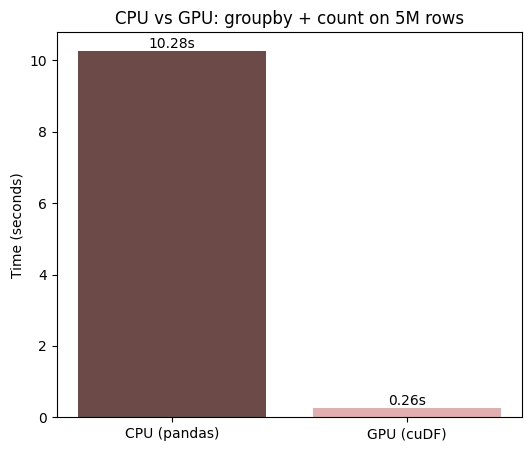

In [20]:
import matplotlib.pyplot as plt

labels = ["CPU (pandas)", "GPU (cuDF)"]
times = [cpu_time, gpu_time]

plt.figure(figsize=(6,5))
bars = plt.bar(labels, times, color=["#6b4a47", "#e3aeb0"])
plt.ylabel("Time (seconds)")
plt.title("CPU vs GPU: groupby + count on 5M rows")
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{t:.2f}s", ha="center", va="bottom")
plt.savefig("cpu_vs_gpu_chart.png", dpi=150)
plt.show()